In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [4]:
print(df.shape)

(27, 2)


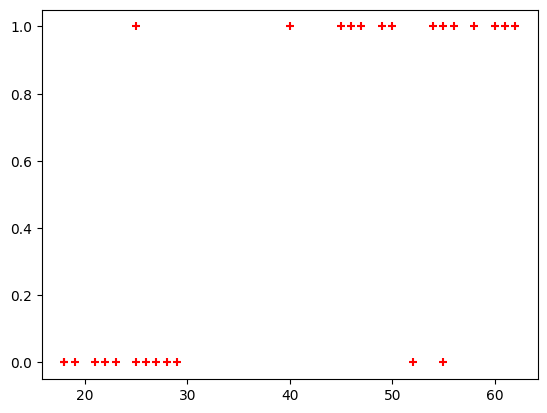

In [8]:
plt.scatter(df.age, df.bought_insurance, color='red', marker='+')

In [14]:
X=df[['age']]
y=df[['bought_insurance']]

In [15]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=10)

In [20]:
X_test

,age
7,60
5,56
18,19
21,26
11,28
1,25


In [22]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

c:\users\dell\appdata\local\programs\python\python39\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [23]:
model.coef_

array([[0.112778]])

In [24]:
model.intercept_

array([-4.20278276])

In [26]:
y_predicted=model.predict(X_test)
y_predicted

array([1, 1, 0, 0, 0, 0], dtype=int64)

In [27]:
df['probs']=model.predict_proba(df[['age']])[:,1]

In [28]:
df

,age,bought_insurance,probs
0,22,0,0.151657
1,25,0,0.200474
2,47,1,0.749845
3,52,0,0.840463
4,46,1,0.728100
5,56,1,0.892140
6,55,0,0.880798
7,60,1,0.928502
8,62,1,0.942103
9,61,1,0.935636


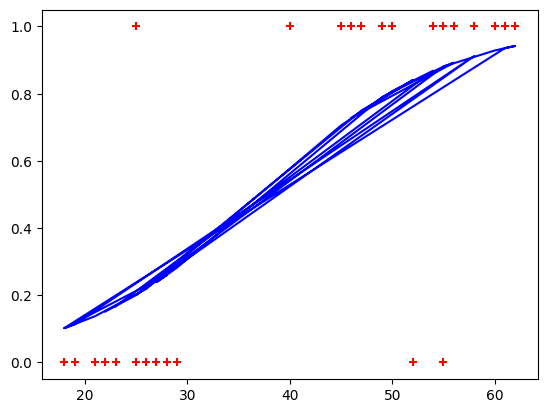

In [30]:
plt.scatter(df.age, df.bought_insurance, color='red', marker='+')
plt.plot(df['age'], df['probs'], color="blue")
plt.show()

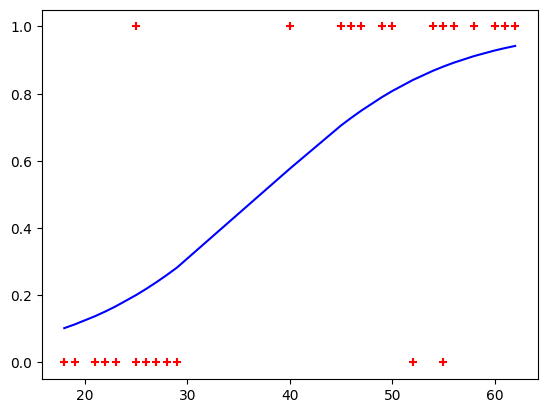

In [31]:
df_sorted = df.sort_values(by='age')

plt.scatter(df.age, df.bought_insurance, color='red', marker='+')
plt.plot(df_sorted['age'], df_sorted['probs'], color='blue')
plt.show()

In [32]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

In [33]:
def prediction(age):
    z=0.112*age+(-4.20)
    y=sigmoid(z)
    return y

In [37]:
age=37
prediction(age)


0.4860036575196728

In [38]:
age=40
prediction(age)


0.569546223939229

In [39]:
age=37.5
prediction(age)


0.5

In [40]:
age=77
prediction(age)


0.9881557756401541

In [41]:
age=1
prediction(age)

0.016496061288316648

In [42]:
age=13
prediction(age)

0.0604264033944818

In [43]:
age=57
prediction(age)

0.8988034760686675

In [44]:
age=58
prediction(age)

0.9085452184644403